### Baixar bibliotecas e definir semente aleatória


In [23]:
import wandb
import pandas as pd
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader , TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp , chi2_contingency
import yaml , random, matplotlib.pyplot as plt
import kagglehub , shutil , os

'''Ao configurar uma seed (semente) global nas bibliotecas, você padroniza o estado inicial
 de qualquer operação pseudo-aleatória muito importante para reprodutibilidade.'''
def set_seed(seed =42):
    random.seed(seed),
    np.random.seed(seed),
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed (42)

### Dicionário de Configuração geral

In [ ]:
config = {
    "data": {
        "raw_path": "data/raw/dataset.csv",
        "test_size": 0.2, # 20% reservados para testes
        "random_state": 42, # Semente para reprodutibilidade
        "target_col": "class", # Coluna alvo
        "missing_threshold": 0.5, # Eliminar colunas com >50% NaN   
        "imputation_strategy": "mean" # Preencher os valores NaN restantes com a média
    }
}

### Login no W&B

In [ ]:
import key

API_KEY = key.KEY 
wandb.login(key=API_KEY)

### Baixar base de dados

In [ ]:
# Download do dataset
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
print(f"Downloaded to: {path}")

# Copia o dataset para a pasta destinada
destination = os.getcwd ()
shutil.copytree(path , os.path.join(destination , "data/"), dirs_exist_ok=True)

# Carregar aquivo principal de acidentes
df_raw = pd.read_csv("data/star_classification.csv", low_memory=False)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns) }...")

### Visualização de dados e análise exploratória de dados


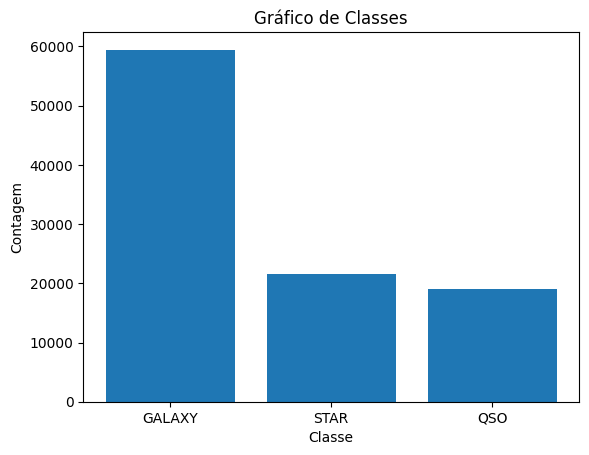

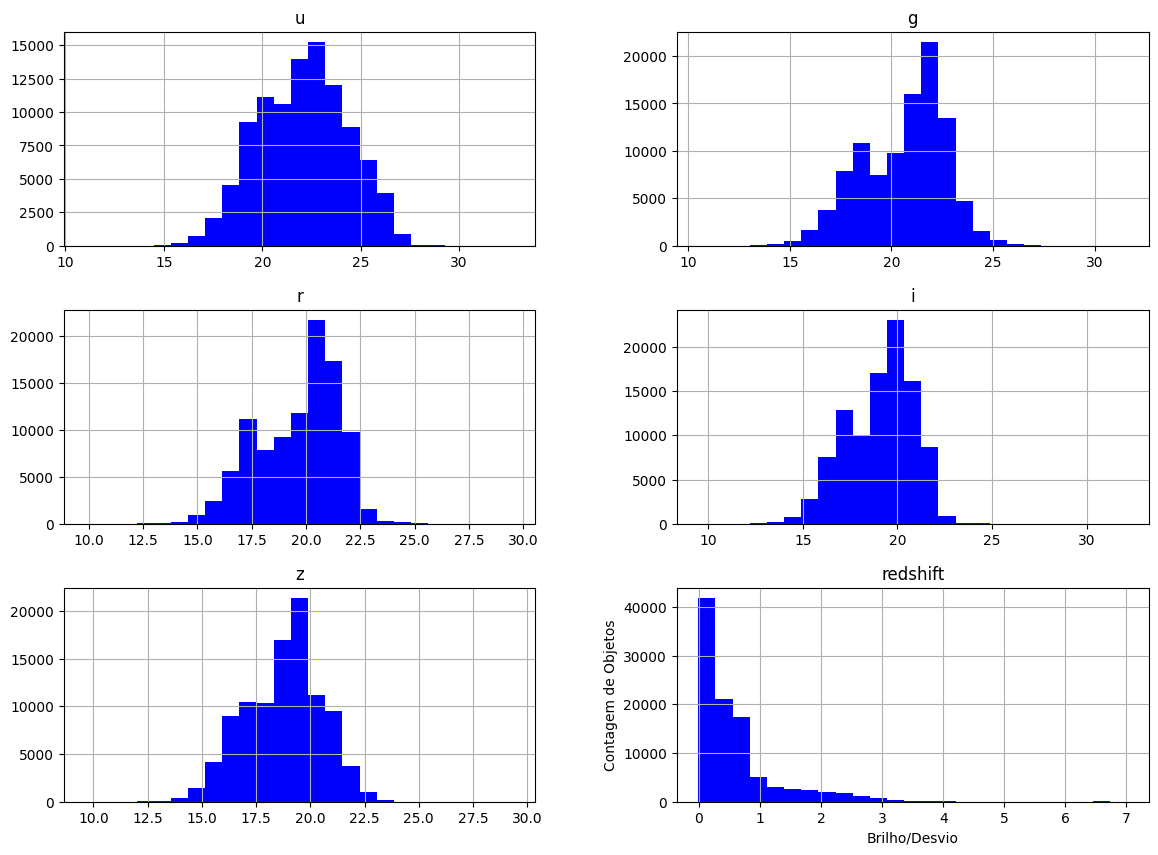

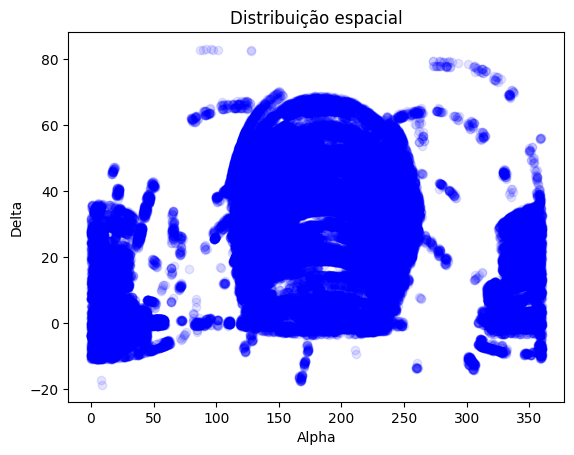

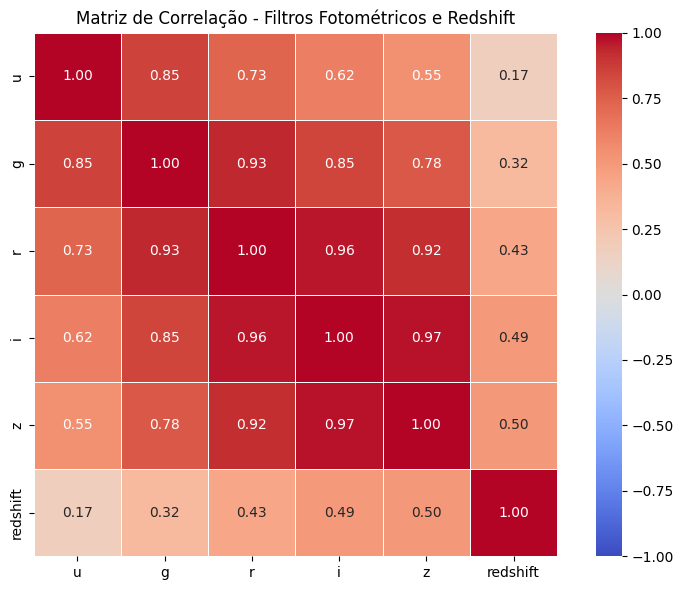

In [35]:
df = pd.read_csv("data/star_classification.csv", sep=",")

# 1. Filtramos os erros para não distorcer a correlação
df_clean = df[(df['u'] > 0) & (df['g'] > 0) & (df['z'] > 0)]

#Gráfico de Barras
cont = df['class'].value_counts()
plt.bar(cont.index, cont.values)
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Gráfico de Classes')
plt.show()

# Histograma das distribuição do todo em cada caracteristica
cols = ['u', 'g', 'r', 'i', 'z', 'redshift'] # Dados relevantes com caracteristicas físicas
df_clean[cols].hist(bins=25, figsize=(14, 10), color="blue")
plt.ylabel("Contagem de Objetos")
plt.xlabel("Brilho/Desvio")
plt.show()

# Gráfico de Dispersão da distribuição dos corpos de acordo com as coordenadas na esfera celeste
plt.scatter(df['alpha'], df['delta'], color="blue", alpha=0.1)
plt.xlabel('Alpha')
plt.ylabel('Delta')
plt.title('Distribuição espacial')
plt.show()

# Mapa de calor 
corr_matrix = df_clean[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,      # Mostra os valores de 'r' em cada célula
    fmt='.2f', 
    cmap='coolwarm', # Azul para negativo, vermelho para positivo
    vmin=-1, vmax=1, # Escala padrão da correlação de Pearson
    linewidths=0.5, 
    square=True
)
plt.title('Matriz de Correlação - Filtros Fotométricos e Redshift')
plt.tight_layout()
plt.show()



### Registrar dados brutos W&B

In [ ]:
wandb.init(project="star-classification", job_type="load_raw", name="load_raw")
artifact = wandb.Artifact("raw_data", type="dataset", description="star_classification raw dataset from Kaggle")
temp_path = "data/temp_raw.csv"
df_raw.to_csv(temp_path , index=False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_raw)
wandb.summary["columns"] = list(df_raw.columns)
wandb.finish()
print("Artefato raw_data salvo no W&B")

"""O procedimento load_raw consiste em registrar os dados brutos como um artefato versionado
 no Weights & Biases imediatamente após a ingestão, garantindo a rastreabilidade"""

### Removendo duplicatas

In [ ]:
def remove_duplicates(df : pd.DataFrame) -> pd.DataFrame:
    """ Removendo as linhas com duplicatas exatas e informando quantas foram removidas"""
    before = len(df)
    df = df.drop_duplicates ()
    removed = before - len (df)
    print ( f" Removeu {removed} linhas "f"({ removed / before :.1%} do dataset)")
    return df

df_clean = remove_duplicates(df_raw)

### Tratando valores em falta

In [ ]:
'''
Tratar valores em falta no DataFrame.

Argumentos:
df: DataFrame de entrada.
strategy: estratégia de imputação para colunas numéricas(’mean’, ’median’, ’most_frequent’).
threshold: as colunas com 50% de falta em valores seram eliminadas.
Retorna:
    DataFrame limpo.
'''

def handle_missing_values(df : pd.DataFrame ,strategy : str = "mean",threshold : float = 0.5) -> pd.DataFrame:

    #Eliminando colunas com muitos valores em falta
    missing_fraction = df.isnull ().mean ()
    cols_to_drop = missing_fraction[missing_fraction > threshold].index.tolist()
    df = df.drop(columns = cols_to_drop)
    print ( f" Colunas eliminadas( >{threshold :.0%} em falta ): {cols_to_drop}")

    #Imputando colunas numéricas
    numeric_cols = df.select_dtypes(include = [np.number]).columns
    imputer = SimpleImputer(strategy = strategy)
    df [numeric_cols] = imputer.fit_transform(df[numeric_cols])

    #Preenchendo as colunas categóricas com um valor provisório
    cat_cols = df.select_dtypes(include =["str"]).columns
    df[cat_cols] = df[cat_cols].fillna("missing")

    return df

df_clean = handle_missing_values (df_clean ,strategy = config["data"]["imputation_strategy"] ,threshold = config["data"]["missing_threshold"])
print ( f" Clean dataset : {len(df_clean)} rows, {df_clean.shape[1]} columns")

### Registrar dados limpos W&B


In [ ]:
wandb.init(project ="star-classification",job_type ="clean_data",name ="clean_data")
artifact = wandb.Artifact("clean_data",type = "dataset", description ="star_classification after deduplication and imputation")
temp_path = "data/temp_clean.csv"
df_clean.to_csv(temp_path, index = False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_clean)
wandb.summary["dropped_columns"] = df_clean.shape[1]
wandb.finish()